In [28]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [39]:
plt.style.use("default")

# Анализ важности признаков моделей прогнозирования комиссий Ethereum

Какие признаки и почему важны при разных горизонтах прогнозирования.  
Для наглядности выбраны 4 модели:

| Тип комиссии | Короткий горизонт | Длинный горизонт |
|---|---|---|
| Base fee | `следующий блок` (~12 с) | `1w` (7 дней) |
| Priority fee | `следующий блок` (~12 с) | `1w` (7 дней) |

In [36]:
plt.rcParams.update({
    # "figure.facecolor": "#0d1117",
    # "axes.facecolor":   "#0d1117",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "text.color":       "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        10,
})

MODELS_DIR = Path("models")

# Загружаем 4 модели
MODELS = {
    "base_next_block": joblib.load(MODELS_DIR / "next_block_lgbm_model.pkl"),
    "base_1w":         joblib.load(MODELS_DIR / "1w_lgbm_model.pkl"),
    "prio_next_block": joblib.load(MODELS_DIR / "priority" / "next_block_priority_lgbm.pkl"),
    "prio_1w":         joblib.load(MODELS_DIR / "priority" / "1w_priority_lgbm.pkl"),
}

# Все 10 моделей — для графика по горизонтам
HORIZONS = ["next_block", "10m", "1h", "1d", "1w"]
HORIZON_LABELS = ["след. блок\n(~12 с)", "10 мин", "1 час", "1 день", "1 неделя"]

ALL_BASE = {h: joblib.load(MODELS_DIR / f"{h}_lgbm_model.pkl") for h in HORIZONS}
ALL_PRIO = {h: joblib.load(MODELS_DIR / "priority" / f"{h}_priority_lgbm.pkl") for h in HORIZONS}

print("Модели загружены:")
for name, m in MODELS.items():
    print(f"  {name}: {len(m.feature_name_)} признаков")

Модели загружены:
  base_next_block: 50 признаков
  base_1w: 27 признаков
  prio_next_block: 39 признаков
  prio_1w: 35 признаков


In [37]:
def get_importance_df(model, top_n=15):
    """Возвращает нормализованные важности признаков, топ-N."""
    total = model.feature_importances_.sum()
    imp = pd.Series(
        model.feature_importances_ / total,
        index=model.feature_name_
    ).sort_values(ascending=False)
    return imp.head(top_n)


CATEGORY_MAP = [
    # (паттерны в имени признака, метка, цвет)
    (["_lag_", "lag_1d", "lag_2d", "lag_1w", "lag_2w", "lag_1", "lag_2", "lag_3"],
     "Лаги",                  "#0098AF"),
    (["_ma_", "ma_1d", "ma_3d", "ma_7d", "ma_1", "ma_3", "trend"],
     "Скользящие средние",    "#355CA8"),
    (["_vol_", "vol_1d", "vol_7d", "vol_1", "volatil"],
     "Волатильность",         "#256569"),
    (["hour", "day_of", "month", "is_weekend", "week_of", "hour_sin", "hour_cos", "day"],
     "Временны́е признаки",   "#f0b429"),
    (["eth_price", "eth_return", "eth_vol", "last_eth"],
     "Цена ETH",              "#e06c75"),
    (["utiliz", "gas_used", "gas_limit", "gas_pres", "tx_per", "tx_change",
      "gas_used_change", "util_lag", "util_ma", "fee_ratio", "fee_diff", "block_util"],
     "Активность сети",       "#98c379"),
]
DEFAULT_CAT = ("Текущие комиссии", "#c678dd")


def categorize(feat_name):
    n = feat_name.lower()
    for patterns, label, color in CATEGORY_MAP:
        if any(p in n for p in patterns):
            return label, color
    return DEFAULT_CAT


def get_category_shares(model):
    """Доля важности по категориям признаков (%), сумма = 100%."""
    total = model.feature_importances_.sum()
    shares = {}
    for feat, imp in zip(model.feature_name_, model.feature_importances_):
        label, _ = categorize(feat)
        shares[label] = shares.get(label, 0.0) + imp / total
    return shares

## 1. Топ-15 признаков: краткосрочные vs долгосрочные модели

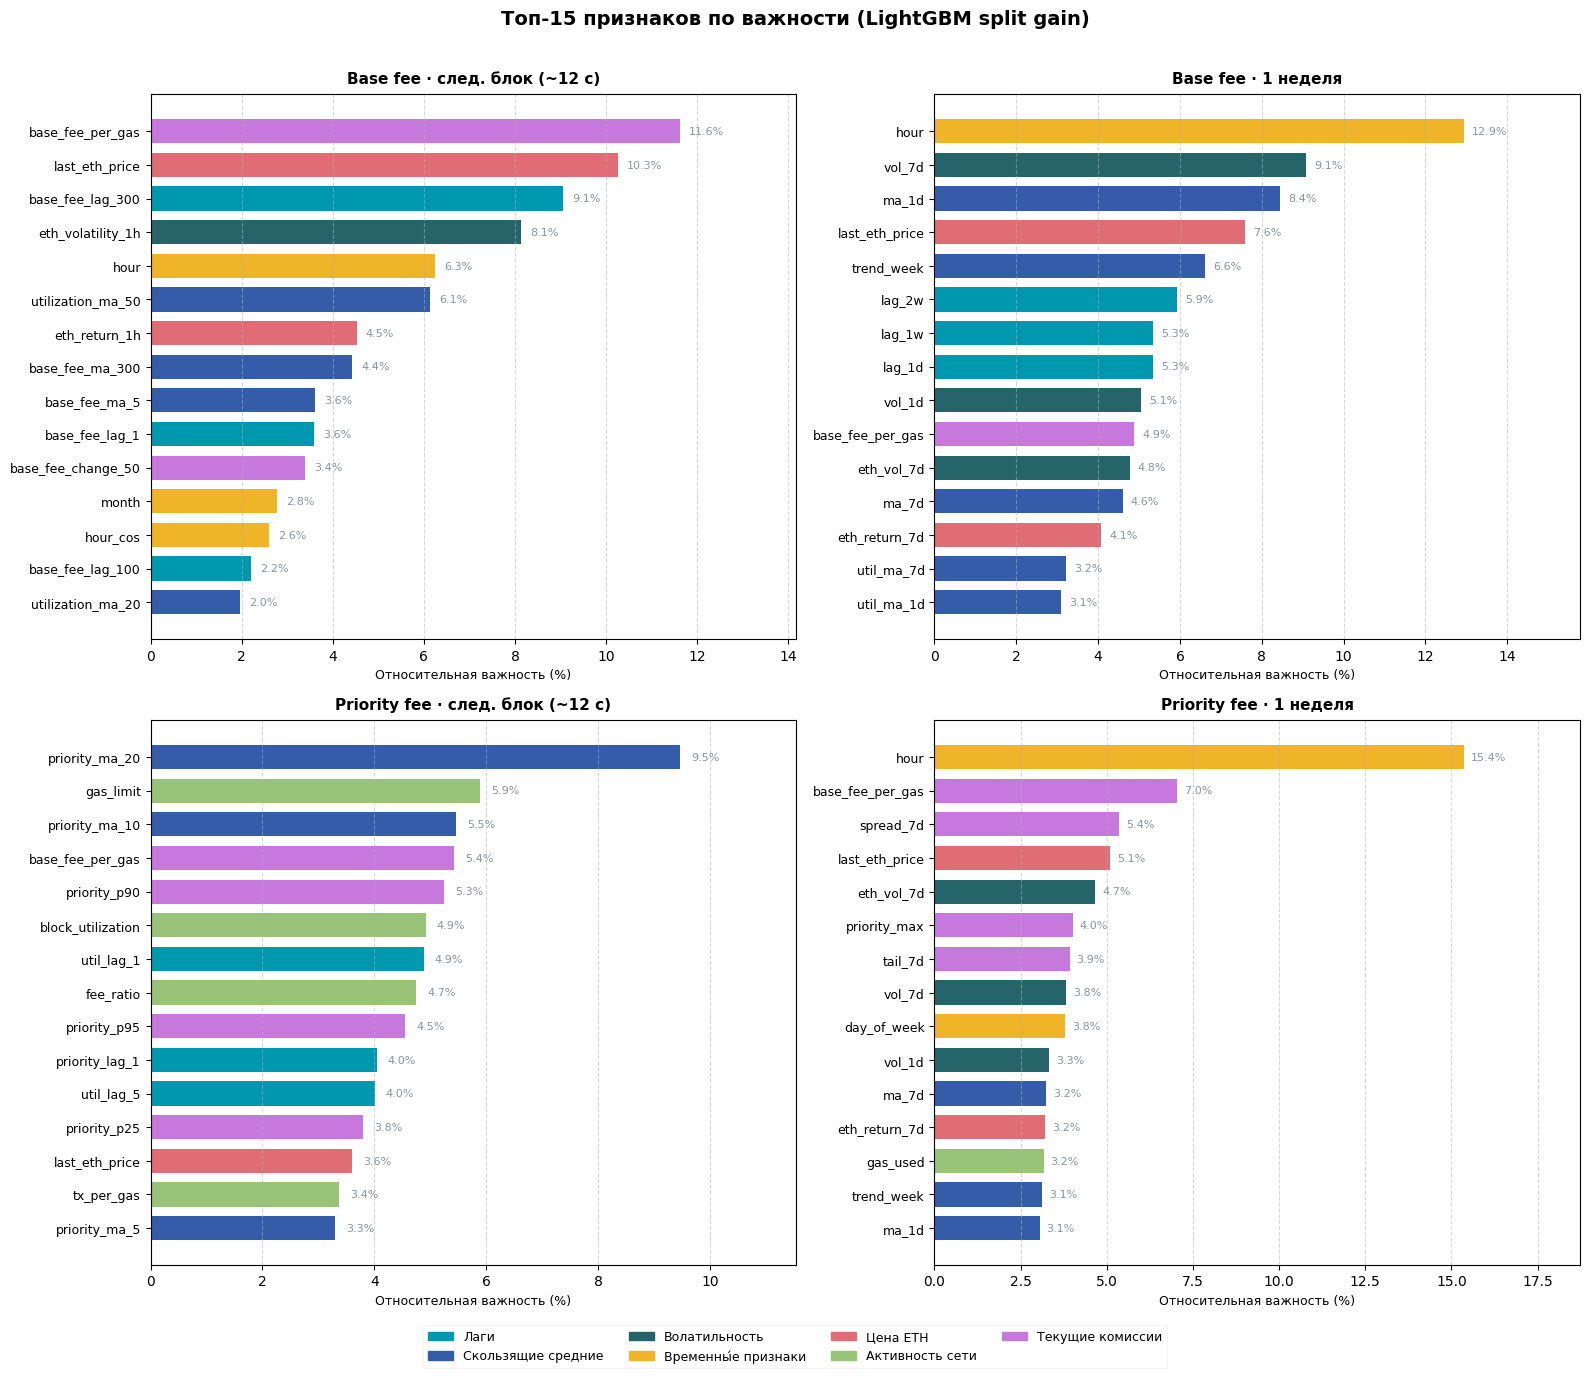

In [40]:
PANEL_TITLES = {
    "base_next_block": "Base fee · след. блок (~12 с)",
    "base_1w":         "Base fee · 1 неделя",
    "prio_next_block": "Priority fee · след. блок (~12 с)",
    "prio_1w":         "Priority fee · 1 неделя",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle(
    "Топ-15 признаков по важности (LightGBM split gain)",
    fontsize=14, fontweight="bold", y=1.01
)

order = ["base_next_block", "base_1w", "prio_next_block", "prio_1w"]
ax_flat = [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]

for ax, key in zip(ax_flat, order):
    model = MODELS[key]
    imp = get_importance_df(model, top_n=15)

    # Цвет каждого бара = категория признака
    colors = [categorize(f)[1] for f in imp.index]

    bars = ax.barh(
        range(len(imp)), imp.values * 100,
        color=colors, edgecolor="none", height=0.72
    )

    # Значения на барах
    for bar, val in zip(bars, imp.values):
        ax.text(
            bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val*100:.1f}%", va="center", fontsize=8, color="#8b949e"
        )

    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Относительная важность (%)", fontsize=9)
    ax.set_title(PANEL_TITLES[key], fontsize=11, fontweight="bold", pad=8)
    ax.grid(True, axis="x", ls="--", alpha=0.5)
    ax.set_xlim(0, imp.values[0] * 100 * 1.22)


legend_handles = [
    mpatches.Patch(color=color, label=label)
    for _, label, color in CATEGORY_MAP
] + [mpatches.Patch(color=DEFAULT_CAT[1], label=DEFAULT_CAT[0])]

fig.legend(
    handles=legend_handles, loc="lower center",
    ncol=4, fontsize=9, framealpha=0.2,
    bbox_to_anchor=(0.5, -0.04)
)

plt.tight_layout()
# plt.savefig("feature_importance_top15.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 2. Смещение важности признаков с ростом горизонта

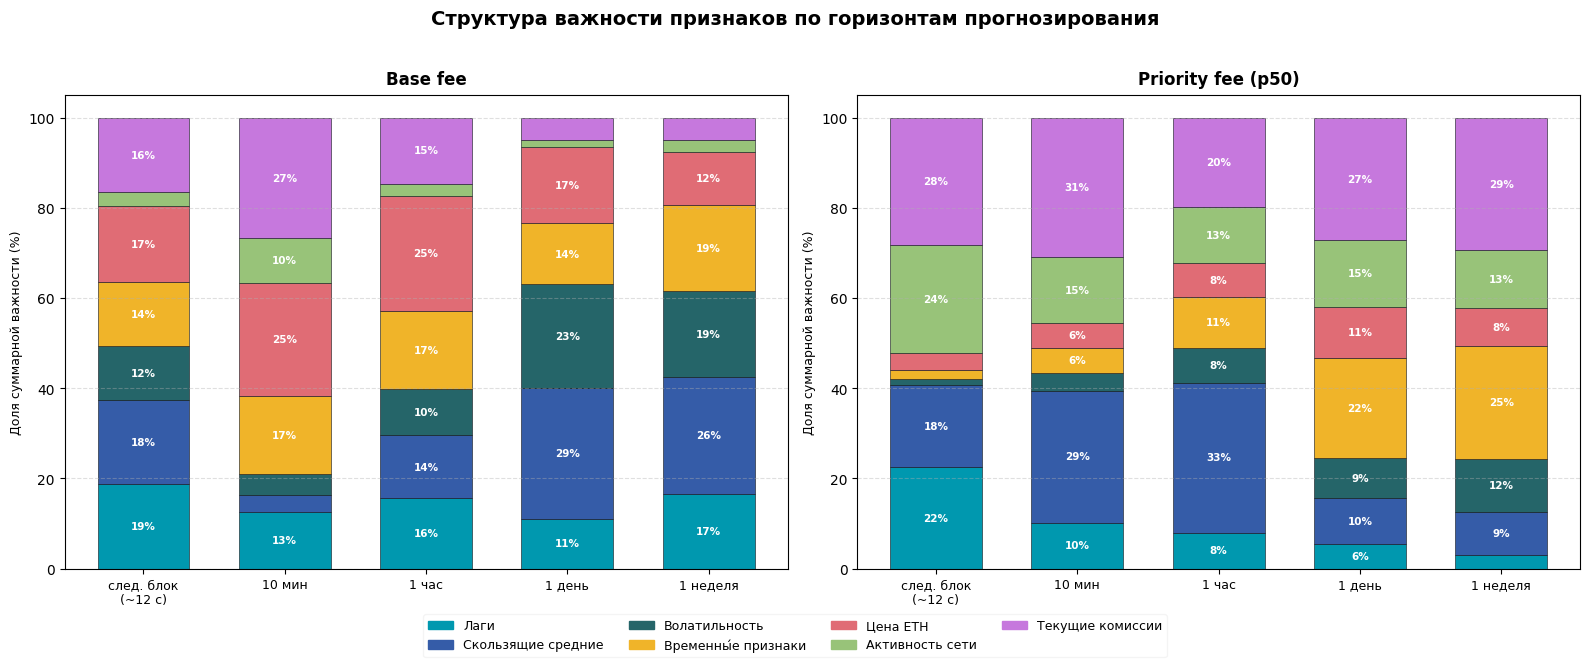

In [41]:
# Собираем матрицы долей по горизонтам 
CAT_LABELS = [label for _, label, _ in CATEGORY_MAP] + [DEFAULT_CAT[0]]
CAT_COLORS = [color for _, _, color in CATEGORY_MAP] + [DEFAULT_CAT[1]]

def build_share_matrix(all_models):
    """Shape: (n_horizons, n_categories)."""
    rows = []
    for h in HORIZONS:
        shares = get_category_shares(all_models[h])
        row = [shares.get(cat, 0.0) * 100 for cat in CAT_LABELS]
        rows.append(row)
    return np.array(rows)  # (5, 7)

base_mat = build_share_matrix(ALL_BASE)
prio_mat = build_share_matrix(ALL_PRIO)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Структура важности признаков по горизонтам прогнозирования",
    fontsize=14, fontweight="bold", y=1.02
)

x = np.arange(len(HORIZONS))
width = 0.65

for ax, mat, title in zip(axes,
                          [base_mat, prio_mat],
                          ["Base fee", "Priority fee (p50)"]):
    bottoms = np.zeros(len(HORIZONS))
    for i, (cat, color) in enumerate(zip(CAT_LABELS, CAT_COLORS)):
        vals = mat[:, i]
        bars = ax.bar(x, vals, width, bottom=bottoms, color=color,
                      label=cat, edgecolor="#0d1117", linewidth=0.4)

        # Подпись внутри сегмента, если он достаточно большой
        for xi, (v, bot) in enumerate(zip(vals, bottoms)):
            if v > 5:
                ax.text(
                    xi, bot + v / 2, f"{v:.0f}%",
                    ha="center", va="center", fontsize=7.5,
                    color="white", fontweight="bold"
                )
        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels(HORIZON_LABELS, fontsize=9)
    ax.set_ylabel("Доля суммарной важности (%)", fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.grid(True, axis="y", ls="--", alpha=0.4)

# Общая легенда
handles = [mpatches.Patch(color=c, label=l)
           for l, c in zip(CAT_LABELS, CAT_COLORS)]
fig.legend(
    handles=handles, loc="lower center", ncol=4,
    fontsize=9, framealpha=0.2, bbox_to_anchor=(0.5, -0.07)
)

plt.tight_layout()
# plt.savefig("feature_importance_shift.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 3. Траектории отдельных категорий

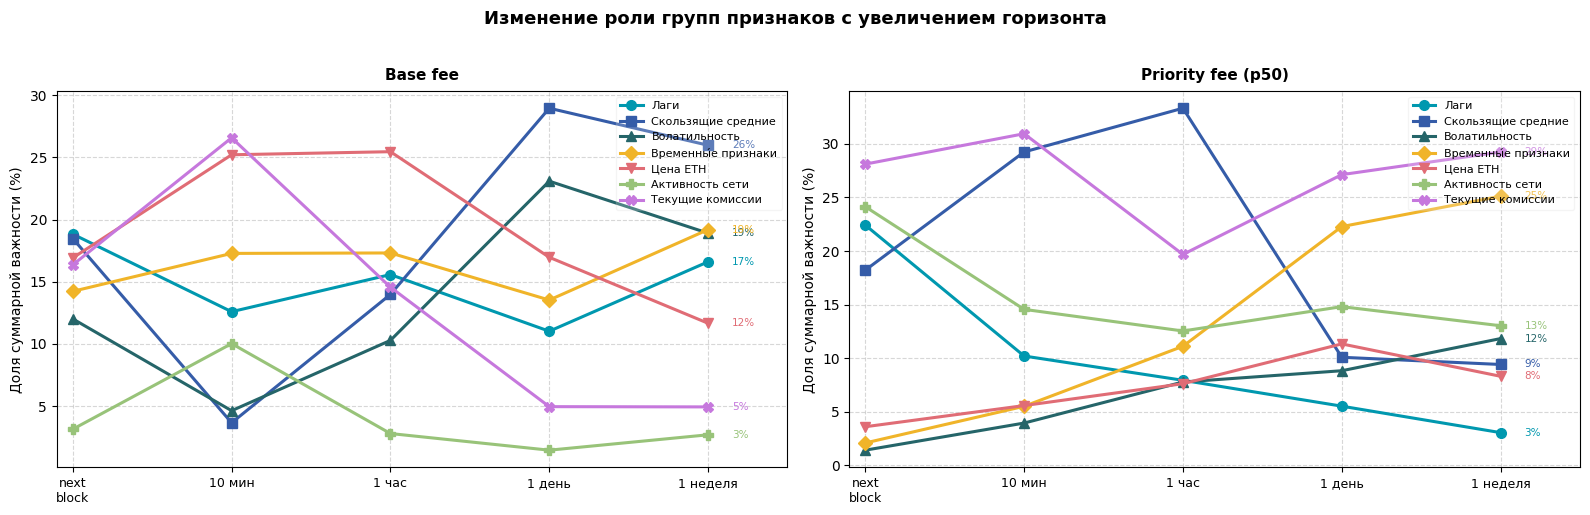

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Изменение роли групп признаков с увеличением горизонта",
    fontsize=13, fontweight="bold", y=1.02
)

x_ticks = ["next\nblock", "10 мин", "1 час", "1 день", "1 неделя"]
x = np.arange(len(HORIZONS))


HIGHLIGHT = [
    "Лаги",
    "Скользящие средние",
    "Волатильность",
    "Временны́е признаки",
    "Цена ETH",
    "Активность сети",
    "Текущие комиссии",
]

MARKERS = ["o", "s", "^", "D", "v", "P", "X"]

for ax, mat, title in zip(axes,
                          [base_mat, prio_mat],
                          ["Base fee", "Priority fee (p50)"]):
    for i, (cat, color, marker) in enumerate(zip(CAT_LABELS, CAT_COLORS, MARKERS)):
        vals = mat[:, i]
        ax.plot(x, vals, color=color, lw=2.2, marker=marker, ms=7, label=cat)
        # Подпись значения на последней точке
        ax.annotate(
            f"{vals[-1]:.0f}%",
            xy=(x[-1], vals[-1]),
            xytext=(x[-1] + 0.15, vals[-1]),
            fontsize=7.5, color=color, va="center"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_ticks, fontsize=9)
    ax.set_ylabel("Доля суммарной важности (%)")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlim(-0.1, len(HORIZONS) - 0.5)
    ax.legend(fontsize=8, framealpha=0.2, loc="upper right")
    ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
# plt.savefig("feature_importance_lines.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 4. Выводы

### Base fee

| Горизонт | Доминирующие группы | Интерпретация |
|---|---|---|
| **следующий блок** | Лаги ≈ МА ≈ ETH price ≈ Текущие комиссии (~17% каждая) | Рынок реагирует на **локальный контекст**: предыдущий fee, скользящие, текущий уровень цен ETH |
| **10 мин** | Текущие комиссии (27%), Цена ETH (25%) | Ключевым становится **абсолютный уровень**: что происходит прямо сейчас |
| **1 час** | Цена ETH (26%), Лаги (16%), МА (14%), Временны́е (17%) | Добавляется **сезонная компонента** (час суток) |
| **1 день** | МА (29%), Волатильность (23%), ETH (17%) | Важны **тренды и неопределённость**: сглаженные значения и стандартное отклонение |
| **1 неделя** | МА (26%), Временны́е (19%), Волатильность (19%) | Прогноз строится на **тренде + сезонности**, роль текущего состояния минимальна |

**Ключевой вывод по base fee:** с ростом горизонта модель переключается с «реактивных» сигналов (текущая комиссия, последний лаг) на «структурные» — скользящие средние и волатильность, отражающие долгосрочный режим сети.

---

### Priority fee

| Горизонт | Доминирующие группы | Интерпретация |
|---|---|---|
| **следующий блок** | Текущие комиссии (28%), Активность сети (24%), Лаги (22%) | Прогноз буквально — «каков fee и загрузка прямо сейчас?» |
| **10 мин** | Текущие комиссии (31%), МА (29%) | Краткосрочная инерция: текущий уровень + сглаженный тренд |
| **1 час** | МА (33%), Текущие (20%), Активность сети (13%) | МА становятся главным предиктором; загрузка ещё значима |
| **1 день** | Текущие (27%), Временны́е (22%), Активность (15%) | Появляется **паттерн времени суток** (22%!) |
| **1 неделя** | Временны́е (25%), Текущие (29%), Волатильность (12%) | **Час суток — признак №1**; модель предсказывает типичный уровень для данного момента недели |

**Ключевой вывод по priority fee:** 
- Краткосрочный прогноз — задача **регрессии на текущее состояние** (сеть реактивна).
- Долгосрочный прогноз — задача **календарного прогнозирования** ("в это время в этот день недели fee обычно такой").
- Роль лагов стремительно падает: от 22% на `next_block` до 3% на `1w` — автокорреляция затухает быстро.

---

- **Короткий горизонт** → **авторегрессионная задача**: лаги, текущее состояние, загрузка сети.
- **Средний горизонт** → **задача сглаживания тренда**: скользящие средние и цена ETH.
- **Длинный горизонт** → **задача паттерн-распознавания**: сезонность (час/день недели) и волатильность режима.